In [ ]:
import pandas as pd
import numpy as np

from pprint import pprint

# models
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

import time

In [49]:
df = pd.read_csv(
    filepath_or_buffer="burnout_cleaned.csv"
)

In [50]:
df.head()

,user_id,day_type,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,sleep_hours,task_completion_rate,burnout_score,burnout_risk
0,1,1,9.59,11.86,4,2,0,7.55,91.2,19.17,0
1,1,0,7.38,10.33,4,1,0,6.69,82.0,29.70,0
2,1,0,6.31,8.92,1,2,0,8.87,80.6,32.93,0
3,1,1,8.34,10.70,4,1,1,8.13,70.0,45.47,0
4,1,0,6.97,9.83,1,2,0,5.85,67.1,51.61,0


### FEATURE ENGINEERING

In [51]:
df["productivity_per_hour"] = np.where(
    df["work_hours"] != 0,
    np.round(df["task_completion_rate"] / df["work_hours"], 2),
    np.nan
)

In [52]:
df.head()

,user_id,day_type,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,sleep_hours,task_completion_rate,burnout_score,burnout_risk,productivity_per_hour
0,1,1,9.59,11.86,4,2,0,7.55,91.2,19.17,0,9.51
1,1,0,7.38,10.33,4,1,0,6.69,82.0,29.70,0,11.11
2,1,0,6.31,8.92,1,2,0,8.87,80.6,32.93,0,12.77
3,1,1,8.34,10.70,4,1,1,8.13,70.0,45.47,0,8.39
4,1,0,6.97,9.83,1,2,0,5.85,67.1,51.61,0,9.63


In [53]:
df["workload"] = \
    df["work_hours"] + \
    df["meetings_count"] + \
    df["screen_time_hours"]

In [54]:
df.head()

,user_id,day_type,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,sleep_hours,task_completion_rate,burnout_score,burnout_risk,productivity_per_hour,workload
0,1,1,9.59,11.86,4,2,0,7.55,91.2,19.17,0,9.51,25.45
1,1,0,7.38,10.33,4,1,0,6.69,82.0,29.70,0,11.11,21.71
2,1,0,6.31,8.92,1,2,0,8.87,80.6,32.93,0,12.77,16.23
3,1,1,8.34,10.70,4,1,1,8.13,70.0,45.47,0,8.39,23.04
4,1,0,6.97,9.83,1,2,0,5.85,67.1,51.61,0,9.63,17.80


In [55]:
df["sleep_deficit"] = np.round(np.maximum(0, 8 - df["sleep_hours"]), 2)

In [56]:
df.head()

,user_id,day_type,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,sleep_hours,task_completion_rate,burnout_score,burnout_risk,productivity_per_hour,workload,sleep_deficit
0,1,1,9.59,11.86,4,2,0,7.55,91.2,19.17,0,9.51,25.45,0.45
1,1,0,7.38,10.33,4,1,0,6.69,82.0,29.70,0,11.11,21.71,1.31
2,1,0,6.31,8.92,1,2,0,8.87,80.6,32.93,0,12.77,16.23,0.00
3,1,1,8.34,10.70,4,1,1,8.13,70.0,45.47,0,8.39,23.04,0.00
4,1,0,6.97,9.83,1,2,0,5.85,67.1,51.61,0,9.63,17.80,2.15


### AGGREGATION & ANALYTICS

In [57]:
df_numeric = df.drop(columns=["user_id", "burnout_score", "day_type", "burnout_risk"])

In [58]:
df_numeric.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   work_hours             1800 non-null   float64
 1   screen_time_hours      1800 non-null   float64
 2   meetings_count         1800 non-null   int64  
 3   breaks_taken           1800 non-null   int64  
 4   after_hours_work       1800 non-null   int64  
 5   sleep_hours            1800 non-null   float64
 6   task_completion_rate   1800 non-null   float64
 7   productivity_per_hour  1800 non-null   float64
 8   workload               1800 non-null   float64
 9   sleep_deficit          1800 non-null   float64
dtypes: float64(7), int64(3)
memory usage: 140.8 KB


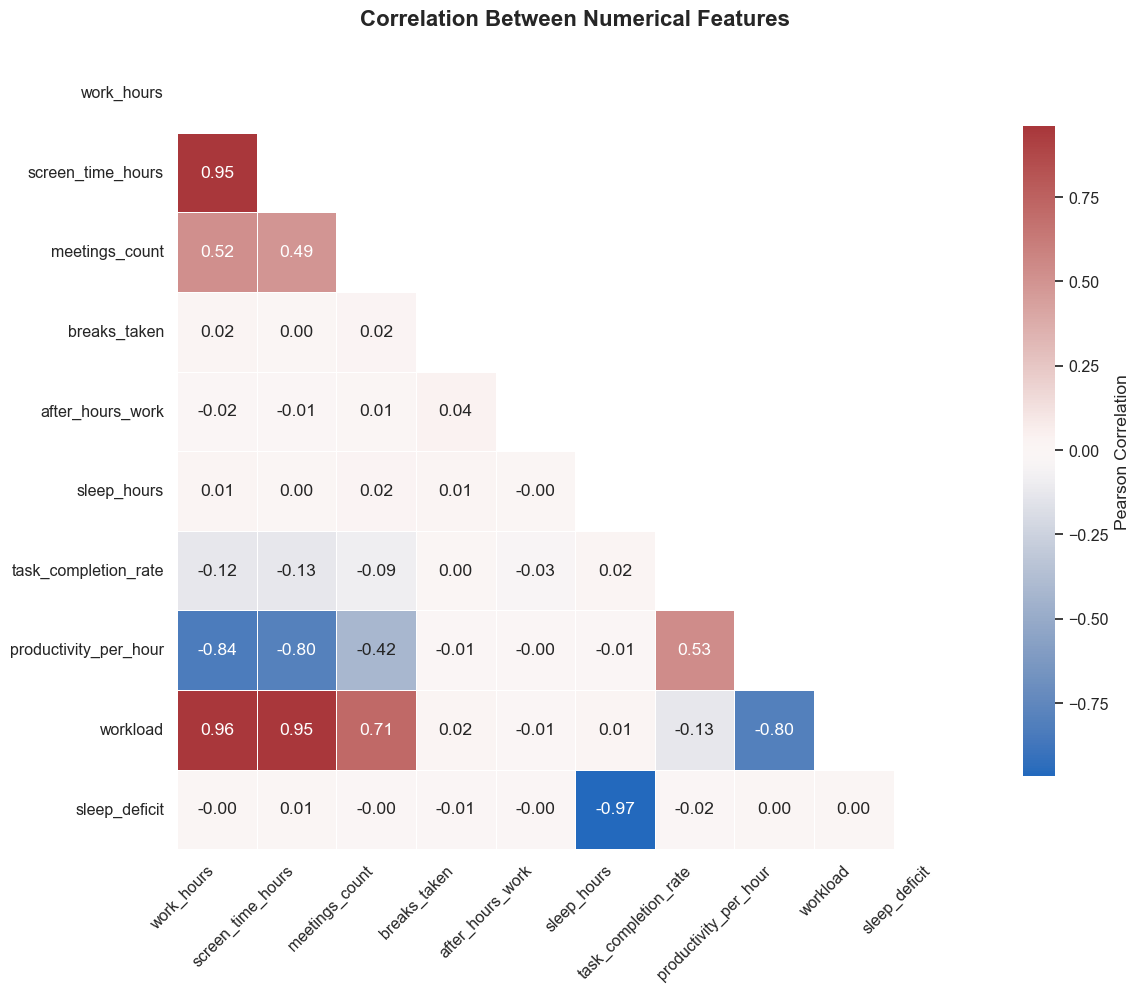

In [59]:
cm = df_numeric.corr(method="pearson")

# Mask upper triangle
mask = np.triu(np.ones_like(cm, dtype=bool))

# Style
sns.set_theme(style="white", font_scale=1.05)

title = "Correlation Between Numerical Features"

plt.figure(figsize=(12, 10))

heatmap = sns.heatmap(
    cm,
    mask=mask,
    cmap="vlag",              
    center=0,
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.7,
    linecolor="white",
    cbar_kws={
        "shrink": 0.8,
        "label": "Pearson Correlation"
    }
)

plt.title(title, fontsize=16, pad=20, weight="bold")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

In [60]:
# NOTE: 
#      0 - Weekend
#      1 - Weekday

stats = (
    df
    .groupby("day_type")
    .agg(
        burnout_risk=("burnout_risk", "mean"),
        sleep_hours=("sleep_hours", "mean"),
        work_hours=("work_hours", "mean"),
        productivity_per_hour=("productivity_per_hour", "mean"),
    )
)

for column in stats.columns:
    stats[column] = np.round(stats[column], 2)

stats

,burnout_risk,sleep_hours,work_hours,productivity_per_hour
day_type,,,,
0,0.14,6.98,4.58,17.21
1,0.19,7.02,8.56,8.41


I will firstly try to work with `burnout_risk` and then pay attention to `burnout_score`.

In [61]:
records_table = pd.DataFrame(columns=["model", "accuracy"])
records_table

,model,accuracy


In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_id                1800 non-null   int64  
 1   day_type               1800 non-null   int64  
 2   work_hours             1800 non-null   float64
 3   screen_time_hours      1800 non-null   float64
 4   meetings_count         1800 non-null   int64  
 5   breaks_taken           1800 non-null   int64  
 6   after_hours_work       1800 non-null   int64  
 7   sleep_hours            1800 non-null   float64
 8   task_completion_rate   1800 non-null   float64
 9   burnout_score          1800 non-null   float64
 10  burnout_risk           1800 non-null   int64  
 11  productivity_per_hour  1800 non-null   float64
 12  workload               1800 non-null   float64
 13  sleep_deficit          1800 non-null   float64
dtypes: float64(8), int64(6)
memory usage: 197.0 KB


### Gradient Boosting Classifier

In [63]:
X = df.drop(
    columns=["user_id", "burnout_score", "burnout_risk"],
)

y = df["burnout_risk"]

In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.35
)

In [65]:
X.head()

,day_type,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,sleep_hours,task_completion_rate,productivity_per_hour,workload,sleep_deficit
0,1,9.59,11.86,4,2,0,7.55,91.2,9.51,25.45,0.45
1,0,7.38,10.33,4,1,0,6.69,82.0,11.11,21.71,1.31
2,0,6.31,8.92,1,2,0,8.87,80.6,12.77,16.23,0.00
3,1,8.34,10.70,4,1,1,8.13,70.0,8.39,23.04,0.00
4,0,6.97,9.83,1,2,0,5.85,67.1,9.63,17.80,2.15


In [66]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: burnout_risk, dtype: int64

In [67]:
gradient_boosting_classifier = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3
)

In [68]:
gradient_boosting_classifier.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [69]:
y_pred = gradient_boosting_classifier.predict(X_test)
gbc_accuracy = np.round(accuracy_score(y_test, y_pred), 2)

In [70]:
print("Accuracy:", gbc_accuracy)

Accuracy: 0.95


In [71]:
records_table.loc[0, "model"] = 'Gradient Boosting Classifier'
records_table.loc[0, "accuracy"] = gbc_accuracy

In [72]:
records_table

,model,accuracy
0,Gradient Boosting Classifier,0.95


### Extreme Gradient Boosting

In [73]:
extreme_gb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    use_label_encoder=False,
    eval_metric="logloss"
)

extreme_gb.fit(X_train, y_train)

d:\IT\venv_win\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:55:35] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [74]:
y_pred = extreme_gb.predict(X_test)
extreme_gb_accuracy = np.round(accuracy_score(y_test, y_pred), 2) 

print("Accuracy:", extreme_gb_accuracy)

Accuracy: 0.95


In [75]:
records_table.loc[1, "model"] = 'Extreme Gradient Boosting'
records_table.loc[1, "accuracy"] = extreme_gb_accuracy

records_table

,model,accuracy
0,Gradient Boosting Classifier,0.95
1,Extreme Gradient Boosting,0.95


### Category Boosting Classifier

In [76]:
cat_boosting = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3.0,
    verbose=False
)

cat_boosting.fit(X_train, y_train)

In [77]:
y_pred = cat_boosting.predict(X_test)
cat_boosting_accuracy = np.round(accuracy_score(y_test, y_pred), 2) 

print("Accuracy:", cat_boosting_accuracy)

Accuracy: 0.95


In [78]:
records_table.loc[2, "model"] = 'Cat Boosting Classifier'
records_table.loc[2, "accuracy"] = cat_boosting_accuracy

In [79]:
records_table.head()

,model,accuracy
0,Gradient Boosting Classifier,0.95
1,Extreme Gradient Boosting,0.95
2,Cat Boosting Classifier,0.95


### Randomized Search of Best Hyperparameters

In [80]:
random_gradient = GradientBoostingClassifier()
random_xgboost = XGBClassifier()

In [81]:
param_gb = {
    "n_estimators": np.arange(100, 500, 50),
    "learning_rate": np.logspace(-3, -1, 20),
    "max_depth": np.arange(3, 8)
}

param_xgb = {
    "n_estimators": np.arange(100, 500, 50),
    "learning_rate": np.logspace(-3, -1, 20),
    "max_depth": np.arange(3, 10),
    "subsample": np.linspace(0.6, 1.0, 5)
}

In [82]:
random_gradient_boosting = RandomizedSearchCV(
    random_gradient,
    param_distributions=param_gb,
    n_iter=30,                       # number of random combos
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    random_state=42,
    verbose=2
)

random_xg_boosting = RandomizedSearchCV(
    random_xgboost,
    param_distributions=param_xgb,
    n_iter=30,                       # number of random combos
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    random_state=42,
    verbose=2
)

In [83]:
print("Random Gradient Boosting...")
random_gradient_boosting.fit(X_train, y_train)

print("Random Extreme Boosting...")
random_xg_boosting.fit(X_train, y_train)

Random Gradient Boosting...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Random Extreme Boosting...
Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'learning_rate': array([0.001 ..., 0.1 ]), 'max_depth': array([3, 4, 5, 6, 7, 8, 9]), 'n_estimators': array([100, 1...50, 400, 450]), 'subsample': array([0.6, 0....8, 0.9, 1. ])}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variou

In [84]:
print("Best parameters for Random Gradient Boosting:", random_gradient_boosting.best_params_)
print("Best parameters for Random Extreme Boosting:", random_xg_boosting.best_params_)

Best parameters for Random Gradient Boosting: {'n_estimators': np.int64(100), 'max_depth': np.int64(3), 'learning_rate': np.float64(0.008858667904100823)}
Best parameters for Random Extreme Boosting: {'subsample': np.float64(0.9), 'n_estimators': np.int64(450), 'max_depth': np.int64(3), 'learning_rate': np.float64(0.008858667904100823)}


In [85]:
y_pred_gradient = random_gradient_boosting.predict(X_test)
y_pred_xgb = random_xg_boosting.predict(X_test)

gradient_boosting_accuracy = np.round(accuracy_score(y_test, y_pred_gradient), 2)
xgb_boosting_accuracy = np.round(accuracy_score(y_test, y_pred_xgb), 2)

In [86]:
records_table.loc[3, "model"] = "Random Gradient Boosting Classifier"
records_table.loc[3, "accuracy"] = gradient_boosting_accuracy

records_table.loc[4, "model"] = "Random Extreme Gradient Boosting Classifier"
records_table.loc[4, "accuracy"] = xgb_boosting_accuracy

In [87]:
records_table

,model,accuracy
0,Gradient Boosting Classifier,0.95
1,Extreme Gradient Boosting,0.95
2,Cat Boosting Classifier,0.95
3,Random Gradient Boosting Classifier,0.95
4,Random Extreme Gradient Boosting Classifier,0.95


### Exhaustive Search of Best Hyperparameters (GridSearchCV)

In [88]:
model = GradientBoostingClassifier()

In [89]:
param_grid = {
    "n_estimators": np.arange(100, 500, step=25),
    "learning_rate": np.linspace(0.1, 2, num=25),
    "max_depth": np.arange(3, 8)
}

grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,                 # 5-fold cross validation
    scoring="accuracy",   # metric
    n_jobs=-1,            # use all CPU cores
    verbose=2
)

In [90]:
# grid.fit(X_train, y_train)

In [91]:
# print("Best parameters:", grid.best_params_)
# print("Best CV score:", grid.best_score_)

In [92]:
# y_pred = grid.predict(X_test)
# print("Accuracy:", accuracy_score(y_test, y_pred))